In [1]:
%pip install numpy opencv-python torch matplotlib scipy
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import random  
import time    
import os      
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from collections import deque

from obelix import OBELIX # Environment class needs to be present in the same folder named obelix

Note: you may need to restart the kernel to use updated packages.


### Helper Functions

In [2]:
def decayEpsilon(epsilon, decay_strategy, max_episodes):
    """
    Returns a numpy array of epsilon values per episode according to a decay strategy.

    decay_strategy: list of tuples (decay_type, decay_val)
        decay_val = {'s': start_episode, 'e': end_episode, 'ival': initial_value, 'fval': final_value}
    """
    epsilons = np.zeros(max_episodes, dtype=np.float32)
    next_decay_episode = 0

    for decay_type, decay_val in decay_strategy:
        s = decay_val['s']
        e = decay_val['e']

        # Fill gaps before this decay segment
        if next_decay_episode < s:
            epsilons[next_decay_episode:s] = decay_val.get('ival', epsilon)

        # Length of current decay segment
        length = e - s + 1
        length = min(length, len(epsilons) - s)  # avoid overshooting

        if decay_type == "linear":
            start_val = decay_val['ival']
            end_val = decay_val['fval']
            epsilons[s:s+length] = np.linspace(start_val, end_val, num=length, dtype=np.float32)

        elif decay_type == "exponential":
            start_val = decay_val['ival']
            end_val = decay_val['fval']
            # decay rate
            decay_rate = np.log(end_val / start_val) / (length - 1)
            epsilons[s:s+length] = start_val * np.exp(decay_rate * np.arange(length))

        else:
            # constant value
            epsilons[s:s+length] = decay_val.get('ival', epsilon)

        next_decay_episode = e + 1

    # Fill remaining episodes if any
    if next_decay_episode < max_episodes:
        epsilons[next_decay_episode:] = decay_val.get('fval', epsilon)

    return epsilons

In [3]:
def huberLoss(error, delta, weights=None, norm=False):
    #this function calculates the huber loss for the error using the delta parameter

    #Your code goes in here
    abs_error = torch.abs(error)
    quadratic = torch.clamp(abs_error, max=delta)
    linear = abs_error - quadratic

    loss = 0.5 * quadratic**2 + delta * linear

    if weights is None:
        hLoss = torch.mean(loss)
    elif not norm:
        hLoss = torch.mean(weights * loss)
    else:
        hLoss = weights * loss
        hLoss = hLoss.sum() / weights.sum()
    return hLoss

### Action Selection Logic

In [ ]:
def selectGreedyActionREP_COMP(net, state, **kwargs):
    device = next(net.parameters()).device

    if not isinstance(state, torch.Tensor):
        state = torch.FloatTensor(state).to(device)
    if state.ndim == 1:
        state = state.unsqueeze(0)  # [1, state_dim]

    with torch.no_grad():
        q_values, _, _, hx, cx = net(state, kwargs['hx'], kwargs['cx'])

    # selecting action with highest q value
    greedyAction = torch.argmax(q_values, dim=1).item()

    return greedyAction, hx, cx


def selectEpsilonGreedyActionREP_NOISY(net, state, epsilon, **kwargs):
    device = next(net.parameters()).device

    if not isinstance(state, torch.Tensor):
        state = torch.FloatTensor(state).to(device)
    if state.ndim == 1:
        state = state.unsqueeze(0)
    
    with torch.no_grad():
        q_values, _, _, hx, cx = net(state, kwargs['hx'], kwargs['cx'])
        
    q_values = q_values.squeeze(0)
    
    # actions = ["L45", "L22", "FW", "R22", "R45"]
    prob_dist = torch.tensor([0.15, 0.15, 0.40, 0.15, 0.15], device=device)
   
    # noisy exploration
    if np.random.rand() >= epsilon:
        # here, i have planned to use noisy exploration-exploitation initially it promotes exploration later as noise_std
        # decays it switches to exploiting the action learnt.
        noise_std = kwargs.get('noise_std', 0.2)
        episode = kwargs.get('episode', 0)
        max_episodes = kwargs.get('max_episodes', 800)

        # decay from noise_std → 0.02 over training
        decay_factor = max(0.1, 1.0 - episode / max_episodes)
        effective_std = noise_std * decay_factor

        # finding noisy q values by adding radnomess and then selct action
        noise_q = q_values + effective_std * torch.randn_like(q_values)
        action = torch.argmax(noise_q).item()

    else:
        # and for epsilon times, still dont want to go completely random, so i tried out biased exploration here
        # with FW action having higher chances of being selected
        # although i wont help me because other actions favours spinning and there prob. dist is still more diversed.
        action = torch.multinomial(prob_dist, 1).item()

    return action, hx, cx

### Sequence Replay Buffer

In [ ]:
class SeqReplayBuffer():
    def __init__(self, bufferSize, seq_len = 8, batchSize = 32, **kwargs):

        #Your code goes in here
        self.bufferSize = bufferSize
        self.seqLen = seq_len
        self.batchSize = batchSize
        self.max_steps = kwargs['max_steps']

        self.actions = ["L45", "L22", "FW", "R22", "R45"]

        # this is for storing complete sequences of expereinces in an episode
        self.buffer = deque(maxlen=self.bufferSize)
        # this is for storng experiences within an episodes and gets reset after an episode ends.
        self.temporaryBuffer = deque(maxlen=self.max_steps)
        # this holds the priorities of individual expereinces being selectedd ahead
        # once episode finishes then all these sequnce priorities stores in priorites deque and thos gets reset
        self.temporaryPriorities = deque(maxlen=self.max_steps)

        self.alpha = kwargs.get("alpha")
        self.beta = kwargs.get("beta")
        self.beta_rate = kwargs.get("beta_rate")

        # this holds the priorites for each experience within a sequence
        self.priorities = deque(maxlen=self.bufferSize)
        # this holds the priorites for complete episodes to select which episode sequences to select first
        # then seq_num number of experiences within the episode will be selected based on 'priorities' deque.
        self.prioritiesOverEpisodes = deque(maxlen=self.bufferSize)

    def storeStepwiseExperiences(self, experience):
        #Your code goes in here
        max_priority = 1.0 if len(self.temporaryPriorities) == 0 else max(self.temporaryPriorities)
        self.temporaryBuffer.append(experience)
        self.temporaryPriorities.append(max_priority)

    def store(self):
        #Your code goes in here
        timeSeriesExperiences = list(self.temporaryBuffer)
        timeSeriesPriorities = list(self.temporaryPriorities)

        self.temporaryBuffer.clear()
        self.temporaryPriorities.clear()

        self.buffer.append(timeSeriesExperiences)
        self.priorities.append(timeSeriesPriorities)
        max_priority = 1.0 if len(self.prioritiesOverEpisodes) == 0 else max(self.prioritiesOverEpisodes)
        self.prioritiesOverEpisodes.append(max_priority)


    def update(self, td_errors_all, indices, start_indices):
        # td_errors_all shape: (B, seq_len)
        # indices shape: (B, ep_idx)
        if isinstance(td_errors_all, list):
            # list of tensors → stack along dim=1
            td_errors_all = torch.stack(td_errors_all, dim=1).detach().cpu().numpy()
        elif isinstance(td_errors_all, torch.Tensor):
            # single tensor → just detach and convert
            td_errors_all = td_errors_all.detach().cpu().numpy()
        else:
            raise TypeError(f"td_errors_all must be Tensor or list of Tensors, got {type(td_errors_all)}")
        
        for batch_idx, ep_idx in enumerate(indices):
            start = start_indices[batch_idx]
            episode_stepwise = self.priorities[ep_idx]

            # updating only the sampled segment
            episode_stepwise[start:start+td_errors_all.shape[1]] = td_errors_all[batch_idx].tolist()

            # updating episode-level priority as mean of stepwise
            self.prioritiesOverEpisodes[ep_idx] = np.mean(episode_stepwise) + 1e-6


    def sample(self, **kwargs):
        priorities = np.array(self.prioritiesOverEpisodes, dtype=np.float32)

        # cleaning priorities if nan exists
        priorities = np.nan_to_num(priorities, nan=1e-6, posinf=1.0, neginf=1e-6)
        priorities = np.abs(priorities) + 1e-6
        probs = priorities ** self.alpha

        # cleaning probabailtites
        probs = np.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0)
        prob_sum = probs.sum()

        if prob_sum <= 0 or not np.isfinite(prob_sum):
            probs = np.ones(len(probs)) / len(probs)
        else:
            probs = probs / prob_sum

        batch_experiences = []
        batch_weights = []
        start_indices = []

        N = self.length()
        batch = min(self.batchSize, N)

        # selcting the episodes indices from where sequencial expeiences being sampled, using probs calculatedd above
        indices = np.random.choice(N, batch, replace=True, p=probs)
        updatedBeta = min(1.0, self.beta + self.beta_rate * kwargs['running_step'])

        for idx in indices:
            episode = self.buffer[idx]
            ep_prios = self.priorities[idx]

            ep_prios = np.nan_to_num(ep_prios, nan=1e-6, posinf=1.0, neginf=1e-6)
            valid_len = len(episode) - self.seqLen + 1

            # since i have tried both things here, first seleecting the sequence starting point rnadomly or using prioriites stored
            if kwargs.get('priority_seq_sampling', False):
                if valid_len > 0:
                    # considering segment seq priorities till len(seq) - seq_len since starting index will be decided among them only
                    segment_prios = ep_prios[:valid_len]
                    segment_prios = np.abs(segment_prios) + 1e-6
                    segment_probs = segment_prios ** self.alpha
                    segment_probs /= segment_probs.sum()

                    start = np.random.choice(valid_len, p=segment_probs)
                else:
                    start = 0
            else:
                # pick a random contiguous segment
                if valid_len > 0:
                    start = np.random.randint(0, valid_len)
                else:
                    start = 0

            segment = episode[start:start+self.seqLen]
            segment_prios = ep_prios[start:start+self.seqLen]
            segment_prios = list(segment_prios)

            # Pad if episode shorter than seqLen
            while len(segment) < self.seqLen:
                segment.append(segment[-1])
                segment_prios.append(1e-6)

            batch_experiences.append(segment)
            start_indices.append(start)

            # weight computation for eliminating priority overestimation caused by sampling action based on prioties (dervied using td-error)
            seg_prios_np = np.abs(np.array(segment_prios, dtype=np.float32))
            seg_prios_np = np.nan_to_num(seg_prios_np, nan=1e-6)
            mean_prio = max(seg_prios_np.mean(), 1e-6)

            w = (N * mean_prio) ** (-updatedBeta)
            batch_weights.append(w)

        batch_weights = np.array(batch_weights, dtype=np.float32)

        # normalizing safely
        max_w = batch_weights.max()
        if max_w <= 0 or not np.isfinite(max_w):
            batch_weights = np.ones_like(batch_weights)
        else:
            batch_weights /= max_w

        return batch_experiences, indices, batch_weights, start_indices

  
    def splitExperiences(self, sequences):
        # sequences: list of list of (s,a,r,ns,d)
        batch_size = len(sequences)
        seq_len = len(sequences[0])

        states = np.zeros((batch_size, seq_len, len(sequences[0][0][0])), dtype=np.float32)
        actions = np.zeros((batch_size, seq_len), dtype=np.int64)
        rewards = np.zeros((batch_size, seq_len), dtype=np.float32)
        nextStates = np.zeros((batch_size, seq_len, len(sequences[0][0][0])), dtype=np.float32)
        dones = np.zeros((batch_size, seq_len), dtype=np.float32)

        for i, seq in enumerate(sequences):
            for t, (s, a, r, ns, d) in enumerate(seq):
                states[i, t] = np.array(s, dtype=np.float32)
                actions[i, t] = a
                rewards[i, t] = r
                nextStates[i, t] = np.array(ns, dtype=np.float32)
                dones[i, t] = d

        return states, actions, rewards, nextStates, dones
    
    
    def length(self):
        #Your code goes in here
        #
        buffersize = len(self.buffer)
        return buffersize

### Network Class

In [ ]:
class KnowledgeNet(nn.Module):
    def __init__(self, inDim=18, outDim=5, f_hDim=[512, 256], lstm_hDim=128, for_hDim=[256, 256], inv_hDim=[256, 256], activation=nn.ReLU):
        super(KnowledgeNet, self).__init__()
        self.activation = activation

        prevDim = inDim
        layers = []
        for nextDim in f_hDim:
            layers.append(nn.Linear(prevDim, nextDim))
            layers.append(self.activation())
            prevDim = nextDim
        self.features = nn.Sequential(*layers)
        self.lstmCell = nn.LSTMCell(prevDim, lstm_hDim)

        # Q head 
        self.values = nn.Linear(lstm_hDim, 1)
        self.advantages = nn.Linear(lstm_hDim, outDim)

        # bad state head (for deciding whether current state in which robot is, either good (away from wall) or bad (touching wall))
        self.bad_state_head = nn.Linear(lstm_hDim, 1)

        # Forward model: (z_t,a_t) -> z_{t+1}
        prevDim = lstm_hDim + outDim
        forward_layers = []
        for nextDim in for_hDim:
            forward_layers.append(nn.Linear(prevDim, nextDim))
            forward_layers.append(self.activation())
            prevDim = nextDim
        forward_layers.append(nn.Linear(prevDim, lstm_hDim))
        self.forward_model = nn.Sequential(*forward_layers)

        # Inverse model: (z_t, z_{t+1}) -> a_t
        prevDim = 2 * lstm_hDim
        inverse_layers = []
        for nextDim in inv_hDim:
            inverse_layers.append(nn.Linear(prevDim, nextDim))
            inverse_layers.append(self.activation())
            prevDim = nextDim
        inverse_layers.append(nn.Linear(prevDim, outDim))
        self.inverse_model = nn.Sequential(*inverse_layers)

        # latent represenation
        self.latent_proj = nn.Sequential(
            nn.Linear(lstm_hDim, lstm_hDim),
            nn.ReLU(),
            nn.LayerNorm(lstm_hDim)
        )

        # Bump Head (for decinding whther infrared bit detcted robot or wall)
        self.bump_head = nn.Sequential(
            nn.Linear(lstm_hDim+2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )


    def _init_weights(self):
        # Linear layers in features block
        for layer in self.features:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        # LSTMCell has 4 gates, weights are stacked
        nn.init.xavier_uniform_(self.lstmCell.weight_ih)
        nn.init.xavier_uniform_(self.lstmCell.weight_hh)
        nn.init.zeros_(self.lstmCell.bias_ih)
        nn.init.zeros_(self.lstmCell.bias_hh)

        # Q Heads
        nn.init.xavier_uniform_(self.values.weight)
        nn.init.zeros_(self.values.bias)
        nn.init.xavier_uniform_(self.advantages.weight)
        nn.init.zeros_(self.advantages.bias)

        # Forward Model
        for layer in self.forward_model:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        # Inverse Model
        for layer in self.inverse_model:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

        # Bump Head
        for layer in self.bump_head:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)


    def forward(self, x, hx, cx):
        x_f = self.features(x)

        # here hx is hidden state for passing shport tem context to the next state
        # while cx holds the long term context and decides based on experiencing the env what to retain and what to forget
        hx, cx = self.lstmCell(x_f, (hx, cx))

        z_t = self.latent_proj(hx) # latent representaion

        v = self.values(z_t)
        adv = self.advantages(z_t)
        q = v + (adv - adv.mean(dim=1, keepdim=True))

        bad_state_logit = self.bad_state_head(z_t)
        return q, z_t, bad_state_logit, hx, cx

### Final Algorithm

In [ ]:
class D3QN_PER():
    def __init__(self, env1, env2, config):
        #Your code goes in here
        self.seed = config['seed']
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        random.seed(self.seed)
        torch.cuda.manual_seed_all(self.seed)
        self.env1 = env1
        self.env2 = env2

        self.gamma = config['gamma']
        self.tau = config['tau']
        self.alpha = config['alpha']
        self.beta = config['beta']
        self.beta_rate = config['beta_rate']
        self.delta = config['delta']
        self.seqLen = config['seq_len']
        self.f_hDim = config['f_hDim']
        self.lstm_hDim = config['lstm_hDim']
        self.burn_in = config['burn_in']
        self.minSamples = config['minSamples']
        self.sampleAction = config['sample_action'] if 'sample_action' in config else False
        
        self.for_hDim = config['for_hDim']
        self.inv_hDim = config['inv_hDim']
        self.alpha_f = config['alpha_f']
        self.beta_i = config['beta_i']
        self.eta = config['eta']
        self.noise_std = config['noise_std']

        self.MAX_TRAIN_EPISODES = config['MAX_TRAIN_EPISODES']
        self.MAX_EVAL_EPISODES = config['MAX_EVAL_EPISODES']

        self.bufferSize = config['bufferSize']
        self.batchSize = config['batchSize']
        self.updateFrequency = config['updateFrequency']
        self.max_steps = config['max_steps']
        self.device = config['device']

        self.explorationStrategyTrainFn = config['explorationStrategyTrainFn']
        self.explorationStrategyEvalFn = config['explorationStrategyEvalFn']

        self.epsilons = decayEpsilon(
            config['epsilon'],
            config['eps_decay_strategy'],
            self.MAX_TRAIN_EPISODES
        )

        self.initBookKeeping()

        stateDim = 18 
        self.actions = ["L45", "L22", "FW", "R22", "R45"]
        actionDim = len(self.actions)

        self.loss_fn = config['loss_fn']
        self.model_path = config['model_path']

        # creating Q network
        self.nnTarget = KnowledgeNet(
            stateDim, actionDim, f_hDim = self.f_hDim, 
            lstm_hDim = self.lstm_hDim, for_hDim=self.for_hDim, 
            inv_hDim=self.inv_hDim
        ).to(self.device)

        self.nnOnline = KnowledgeNet(
            stateDim, actionDim, f_hDim = self.f_hDim, 
            lstm_hDim = self.lstm_hDim, for_hDim=self.for_hDim, 
            inv_hDim=self.inv_hDim
        ).to(self.device)

        self.nnOnline._init_weights()
        self.updateNetwork(self.nnOnline, self.nnTarget)

        # defining the optimizer using optimizerFn with optimizerLR
        self.optimizer = config['optimizerFn'](self.nnOnline.parameters(), lr=config['optimizerLR'])

        # created replay buffer for D3QN-PER
        self.rBuffer = SeqReplayBuffer(
            self.bufferSize, seq_len=self.seqLen, 
            batchSize=self.batchSize, max_steps=self.max_steps,
            alpha=self.alpha, beta=self.beta, beta_rate=self.beta_rate
        )

    def initBookKeeping(self):
        # Your code goes in here
        self.trainRewardsList = []
        self.evalRewardsList1 = []
        self.evalRewardsList2 = []
        self.trainTimeList = []
        self.wallClockTimeList = []
        self.totalStepsList = []
        self.startTime = time.time()

    def performBookKeeping(self, train = True):
        # Your code goes in here
        currentTime = time.time()
        if train:
            trainTime = currentTime - self.startTime
            self.trainTimeList.append(trainTime)
        else :
            wallClock = currentTime - self.startTime
            self.wallClockTimeList.append(wallClock)

    def runD3QN_PER(self):
        #Your code goes in here
        trainRewardsList, trainTimeList, evalRewardsList1, evalRewardsList2, wallClockTimeList, totalStepsList = self.trainAgent()
        return trainRewardsList, trainTimeList, evalRewardsList1, evalRewardsList2, wallClockTimeList, totalStepsList
    
    def trainAgent(self):
        #Your code goes in here
        self.updateNetwork(self.nnOnline, self.nnTarget)
        for episode in range(self.MAX_TRAIN_EPISODES):
            # Early Exit 
            if os.path.exists("STOP_TRAINING"):
                print(f"Stop signal detected at episode {episode + 1}. Saving and exiting.")
                torch.save(self.nnOnline.state_dict(), f"{self.model_path}/manual_stop_ep{episode + 1}.pth")
                os.remove("STOP_TRAINING")
                break
            
            # training on both envs with and without walls so that agent can visualize betterly
            # and dont overfit to single env
            envs = [self.env1, self.env2]
            envName = ["with walls", "without walls"]
            env_idx = random.randint(0, len(envs) - 1)
            env = envs[env_idx]
            
            self.nnOnline.to(self.device)
            self.nnTarget.to(self.device)
            # first of all, getting the current state of the agent
            state = env.reset(seed = self.seed + 10 * episode)
            
            hx = torch.zeros(1, self.lstm_hDim).to(self.device)
            cx = torch.zeros(1, self.lstm_hDim).to(self.device)
            done = False
            totalRewards = 0
            totalSteps = 0

            while not done:
                # selecting action based on epislon based noisy exploraiton-exploitation
                action, hx, cx = self.explorationStrategyTrainFn(
                    self.nnOnline, state, self.epsilons[episode], 
                    hx=hx, cx=cx, noise_std=self.noise_std,
                    episode=episode,
                    max_episodes=self.MAX_TRAIN_EPISODES
                )

                # observed the new experience by taking one step in the env
                next_state, reward, done = env.step(self.actions[action], render=False)

                # each experience holds the info of curr_state, action_taken, next_state, reward_got, whether_terminated
                experience = (state, action, reward, next_state, done)

                # stotring stepwise expeirinces into the temnproray replay buffer
                self.rBuffer.storeStepwiseExperiences(experience)

                # training will be started only when seq replay buffer has enough samples to sample from the buffer
                # otherwise training will be skewed and hurts eventually
                if self.rBuffer.length() >= self.minSamples and (totalSteps + 1) % 4 == 0:
                    batch_experiences, indices, batch_weights, start_indices = self.rBuffer.sample(running_step=totalSteps)
                    if batch_experiences is None  or indices is None or batch_weights is None or start_indices is None:
                        continue
                    experiences = (batch_experiences, indices, batch_weights, start_indices)
                    self.trainNetwork(episode, experiences)

                state = next_state
                totalRewards += reward
                totalSteps += 1

                """Now updating the target network based on steps"""
                if (totalSteps+1) % self.updateFrequency == 0:
                    self.updateNetwork(self.nnOnline, self.nnTarget)

            # finally calling store method to store stepwise experiences into the replay buffer
            self.rBuffer.store()
            self.performBookKeeping(train=True)

            # appending the totalReward and totalSteps in bookKeeping variables
            self.trainRewardsList.append(totalRewards)
            self.totalStepsList.append(totalSteps)

            # evaluating after every 20th episode and logging accordingly
            if (episode + 1) % 20 == 0:
                evalRewardsFor2Envs = self.evaluateAgent()
                self.evalRewardsList1.append(evalRewardsFor2Envs[0])
                self.evalRewardsList2.append(evalRewardsFor2Envs[1])
                self.performBookKeeping(train=False)
                print(f"Episode {episode+1}: TR({envName[env_idx]}) {self.trainRewardsList[-1]:.3f} | ER(with wall) {self.evalRewardsList1[-1]:.3f} | ER(without wall) {self.evalRewardsList2[-1]:.3f} | TT {self.trainTimeList[-1]:.3f} | WC {self.wallClockTimeList[-1]:.3f} | TS {self.totalStepsList[-1]:.0f}")
                torch.save(self.nnOnline.state_dict(), f"{self.model_path}/lstm_d3qn_rep_bh_dual_w_{episode+1}.pth")

            else:
                print(f"Episode {episode+1}: TR({envName[env_idx]}) {self.trainRewardsList[-1]:.3f} | TT {self.trainTimeList[-1]:.3f} | TS {self.totalStepsList[-1]:.0f}")

        return self.trainRewardsList, self.trainTimeList, self.evalRewardsList1, self.evalRewardsList2, self.wallClockTimeList, self.totalStepsList
    
    def trainNetwork(self, episode, experiences):
        #Your code goes in here
        self.nnOnline.train()
        self.nnTarget.train()
        batch_experiences, indices, batch_weights, start_indices = experiences
        ss, acts, rs, sNexts, dones = self.rBuffer.splitExperiences(batch_experiences)

        # converting python lists into torch tensors
        ss = torch.FloatTensor(ss).to(self.device)
        acts = torch.LongTensor(acts).to(self.device)
        rs = torch.FloatTensor(rs).to(self.device)
        sNexts = torch.FloatTensor(sNexts).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)
        weights = torch.FloatTensor(batch_weights).to(self.device)

        B, T, _ = ss.shape

        # Initializing LSTM hidden states
        hx = torch.zeros(B, self.lstm_hDim).to(self.device)
        cx = torch.zeros(B, self.lstm_hDim).to(self.device)

        loss = 0.0
        td_errors_all = []

        # Burn-in steps (required for LSTM to have past context)
        with torch.no_grad():
            for t in range(self.burn_in):
                _, _, _, hx, cx = self.nnOnline(ss[:, t], hx, cx)

        
        for t in range(self.burn_in, T):
            qs, z_t, bad_state_logit, hx, cx = self.nnOnline(ss[:,t], hx, cx)

            hx_next = hx.detach()
            cx_next = cx.detach()

            # finding z_nexts used by inverse network for determing action in order to 
            # learn good latent represenations and also used by forward model as target
            # for determining loss in order to update its params 
            with torch.no_grad():
                _, z_next, _,  _, _ = self.nnOnline(sNexts[:,t], hx_next, cx_next)
            
            # Forward Model
            # it expects actions in one-hot vector encoding rather than numerics and then predidcts the possiible
            # next representation of the robot and whjich will be learnt based on the z_nexts from next states
            # represenations
            a_onehot = F.one_hot(acts[:,t], num_classes=len(self.actions)).float()
            forward_input = torch.cat([z_t, a_onehot], dim=1)
            z_next_pred = self.nnOnline.forward_model(forward_input)
            forward_loss = F.mse_loss(z_next_pred, z_next.detach(), reduction='none').mean(dim=1)

            # inverse model
            # it accepts output from the forward model and based on current and predicted next state represenation
            # predicts the possible actions which is known to us (and acts as target) for determinign loss
            # so it tries to improve the prediction made by forward model which eventually improves the latent
            # representations
            inverse_input = torch.cat([z_t, z_next.detach()], dim=1)
            a_pred_logits = self.nnOnline.inverse_model(inverse_input)
            inverse_loss = F.cross_entropy(a_pred_logits, acts[:,t], reduction='none')

            # reward shaping
            # i found that vaired and unpropotinality in rewards making the robot to learn
            # good behaviors so i log scaled the rewards by preserving their signs
            # and it allows the agent to explore without being in fear of hitting the wall
            rs_env = torch.sign(rs) * torch.log1p(torch.abs(rs))
            rs_env = torch.where(
                rs_env > 0,
                4.0 * rs_env,          # amplify positives so that if its sensors detects box, it can move towards it and tries to follow it
                rs_env                 # keep negatives same
            )

            # Intrinsic Reward
            # added intrisic reward based on by how much extent it shifts from its current represenatations
            # but later decayed it, since represenations also got changed when it rortates so it eveuntally spins without
            # properly decaying intrinsic reward over episode
            intrinsic_reward = torch.norm(z_next_pred - z_next.detach(), dim=1)
            intrinsic_reward = intrinsic_reward / (intrinsic_reward.std().detach() + 1e-8)
            eta = self.eta * (1 - episode / (0.7 * self.MAX_TRAIN_EPISODES))

            
            # Only motivating the robot when reward is negative. rest handled by progress reward 
            intrinsic_reward = (intrinsic_reward + 1e-3) * (rs_env[:, t] <= 0)

            # bad state loss
            bump = ss[:, t, 16].unsqueeze(1)
            stuck = ss[:, t, 17].unsqueeze(1)

            # bump head expected curr latent represenation along with last two bit info to determine
            # whether ahead is wall or box and it will be trained by using binary targets coming from
            # td_error < mean of last few td errors
            # idea was that since td error tells which action performs well than expected so that means
            # if it is more negative than mean of few td errors then this is a wall and not a bump but still
            # it is in itself is not fully corret so leave on neural network to leanr by interaction and temporal
            # learning.
            bump_input = torch.cat([z_t.detach(), bump, stuck], dim=1)
            bump_bad_logit = self.nnOnline.bump_head(bump_input)
            bump_bad_prob = torch.sigmoid(bump_bad_logit)
            
            # for bad state head, target is defiend as below because stuck is always bad and gets set when either stuck at wall or boundary
            # and have to decide whow much percent of bump is bad using the prob dist from bump logits.
            bad_state_target = stuck + bump * bump_bad_prob.detach().squeeze(1)
            bad_state_penalty = stuck.squeeze(1) + bump.squeeze(1) * bump_bad_prob.detach().squeeze(1)
            bad_state_bump_loss = torch.clip(0.5 * ((bad_state_target - bad_state_logit.squeeze(1)) ** 2), 0, 2).mean()
            
            # Since agent still getting stuck so used this also to avoid getting stuck (extra safety)
            stuck_loss = F.binary_cross_entropy_with_logits(
                bad_state_logit.squeeze(1),
                stuck.squeeze(1)
            )

            # rewarding if sensor detects box 
            # initally my idea was to give more bonus when sensor bits and inrared detects box then over taking forward action, 
            # it should get some bonus but if given more time, this logic can be improved since
            # my agent suffers from this alignment problem still.
            extra_bonus_for_getting_attached_to_box_if_detected = ((ss[:, t, 17]==0).float() * ss[:, t, 16] * ss[:, t, 4:12].mean(dim=1) * (acts[:,t]==2).float()).mean()
            progress_reward =  0.15 * torch.mean(ss[:, t,:16], dim=1) + 0.4 * extra_bonus_for_getting_attached_to_box_if_detected - 0.05 * bad_state_penalty

            total_reward = rs_env[:,t] + max(0.005, eta) * intrinsic_reward + progress_reward

            # D3QN Loss     
            qs_next, _, _, _, _ = self.nnOnline(sNexts[:, t], hx_next, cx_next)
            a_next = qs_next.argmax(dim=1)

            qt_next, _, _, _, _ = self.nnTarget(sNexts[:, t], hx_next, cx_next)
            max_q = qt_next.gather(1, a_next.unsqueeze(1)).squeeze(1)

            td_target = total_reward + self.gamma * max_q.detach() * (1 - dones[:, t])

            q_val = qs.gather(1, acts[:, t].unsqueeze(1)).squeeze(1)
            td_error = td_target - q_val
            td_errors_all.append(td_error)

            # finding bump loss 
            last_few = min(4, len(td_errors_all))
            recent_errors = td_errors_all[-last_few:]
            recent_tensors = [t.detach().float().mean() if isinstance(t, torch.Tensor) else torch.tensor(float(t)) for t in recent_errors]
            mean_of_last_4_td_errors = torch.stack(recent_tensors).mean().item()

            bump_target = (td_error.detach() < mean_of_last_4_td_errors).float()
            bump_loss = (bump.squeeze(1) * F.binary_cross_entropy_with_logits(
                bump_bad_logit.squeeze(1),
                bump_target,
                reduction='none'
            )).mean()

            if self.loss_fn == 'HuberLoss':
                d3qn_loss = huberLoss(td_error, self.delta, weights, norm=True)
            else:
                # weights here are for correcting prioritity bias
                d3qn_loss = (weights * td_error.pow(2)).sum().mean() / weights.sum()


            # total loss
            loss += (
                d3qn_loss + 
                self.alpha_f * (weights * forward_loss).mean() +
                self.beta_i * (weights * inverse_loss).mean() +
                0.1 * bump_loss +
                0.2 * bad_state_bump_loss +
                0.3 * stuck_loss
            )

            done_mask = dones[:,t].unsqueeze(1)
            hx = hx * (1 - done_mask)
            cx = cx * (1 - done_mask)
        
        loss = loss / (T - self.burn_in)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.nnOnline.parameters(), 10)
        self.optimizer.step()
        
        self.rBuffer.update(td_errors_all, indices, start_indices)


    def updateNetwork(self, onlineNet, targetNet):
        #this function updates the onlineNetwork with the target network
        # Your code goes in here
        
        for target_param, online_param in zip(targetNet.parameters(), onlineNet.parameters()):
            target_param.data.copy_(self.tau * online_param.data + (1 - self.tau) * target_param.data)


    def evaluateAgent(self):
        #this function evaluates the agent using the value network, it evaluates agent for MAX_EVAL_EPISODES
        #Your code goes in here

        self.nnOnline.eval()
        self.nnTarget.eval()
        feval = []

        for env in [self.env1, self.env2]:
            temp_eval = []
            for e in range(self.MAX_EVAL_EPISODES):
                # selecting seed randomly for preventing overfitting
                seed = random.randint(0, 10000)
                state = env.reset(seed = seed)
                totalReward = 0
                done = False
                hx = torch.zeros(1, self.lstm_hDim).to(self.device)
                cx = torch.zeros(1, self.lstm_hDim).to(self.device)

                while not done:
                    # during evaluation, action must be selected greedily based on what our model learnt
                    action, hx, cx = self.explorationStrategyEvalFn(self.nnOnline, state, hx=hx, cx=cx)
                    next_state, reward, done = env.step(self.actions[action], render=False)

                    totalReward += reward
                    state = next_state

                temp_eval.append(totalReward)
            feval.append(np.mean(temp_eval).item())

        return feval

### Configuration File

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device used: ', device)

config = {
    'seed': 333,
    'gamma': 0.99,
    'bufferSize': 1_000_000,
    'batchSize': 32,
    'optimizerFn': torch.optim.Adam,
    'optimizerLR': 1e-4,
    'MAX_TRAIN_EPISODES': 1000,
    'MAX_EVAL_EPISODES': 5,
    'updateFrequency': 80,
    'explorationStrategyTrainFn': selectEpsilonGreedyActionREP_NOISY,
    'explorationStrategyEvalFn': selectGreedyActionREP_COMP,
    'max_steps': 1000,
    'epsilon': 0.98,
    'eps_decay_strategy': [
        ("linear", {'s': 0, 'e': 499, 'ival': 1.0, 'fval': 0.25}),
        ("exponential", {'s': 500, 'e': 999, 'ival': 0.28, 'fval': 0.01})
    ],
    'device': device,
    'delta': 0.99,
    'tau': 0.005,
    'alpha': 0.58,
    'beta': 0.42,
    'beta_rate': 0.0002,
    'f_hDim': [324, 256],
    'lstm_hDim': 128,
    'model_path': './model_weights',
    'loss_fn': 'HuberLoss',
    'seq_len': 30,
    'burn_in': 10,
    'minSamples': 40, # represents to collection of one whole sequqnce of experiences
    'for_hDim': [224, 128],
    'inv_hDim': [224, 128],
    'alpha_f': 0.12,
    'beta_i': 0.15,
    'eta': 0.08,
    'noise_std': 0.2
}

device used:  cuda


### Training 

In [10]:
env1 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)

env2 = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=3,
    box_speed=4,
)

D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent = D3QN_PER(env1, env2, config)

In [ ]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList1, d3qnPerEvalRewardsList2, d3qnPerWallClockTimeList, d3qnPerTotalStepsList = D3QN_PER_LSTM_with_REP_BAD_HEAD_Agent.runD3QN_PER()

Episode 1: TR(without walls) -15068.000 | TT 8.791 | TS 1000
Episode 2: TR(without walls) -531.000 | TT 9.207 | TS 54
Episode 3: TR(with walls) -39268.000 | TT 16.884 | TS 1000
Episode 4: TR(without walls) -28373.000 | TT 24.427 | TS 1000
Episode 5: TR(with walls) -14460.000 | TT 29.234 | TS 589
Episode 6: TR(without walls) -72393.000 | TT 42.778 | TS 1000
Episode 7: TR(without walls) -2069.000 | TT 56.516 | TS 1000
Episode 8: TR(without walls) -3510.000 | TT 59.578 | TS 240
Episode 9: TR(without walls) -42978.000 | TT 68.891 | TS 706
Episode 10: TR(with walls) -3034.000 | TT 71.207 | TS 166
Episode 11: TR(without walls) -59596.000 | TT 84.621 | TS 1000
Episode 12: TR(with walls) -62480.000 | TT 98.694 | TS 1000
Episode 13: TR(without walls) -2487.000 | TT 112.231 | TS 1000
Episode 14: TR(with walls) -32781.000 | TT 125.594 | TS 1000
Episode 15: TR(without walls) -30679.000 | TT 139.450 | TS 1000
Episode 16: TR(with walls) -38175.000 | TT 152.901 | TS 1000
Episode 17: TR(without walls)

### Training and Evaluation Plots

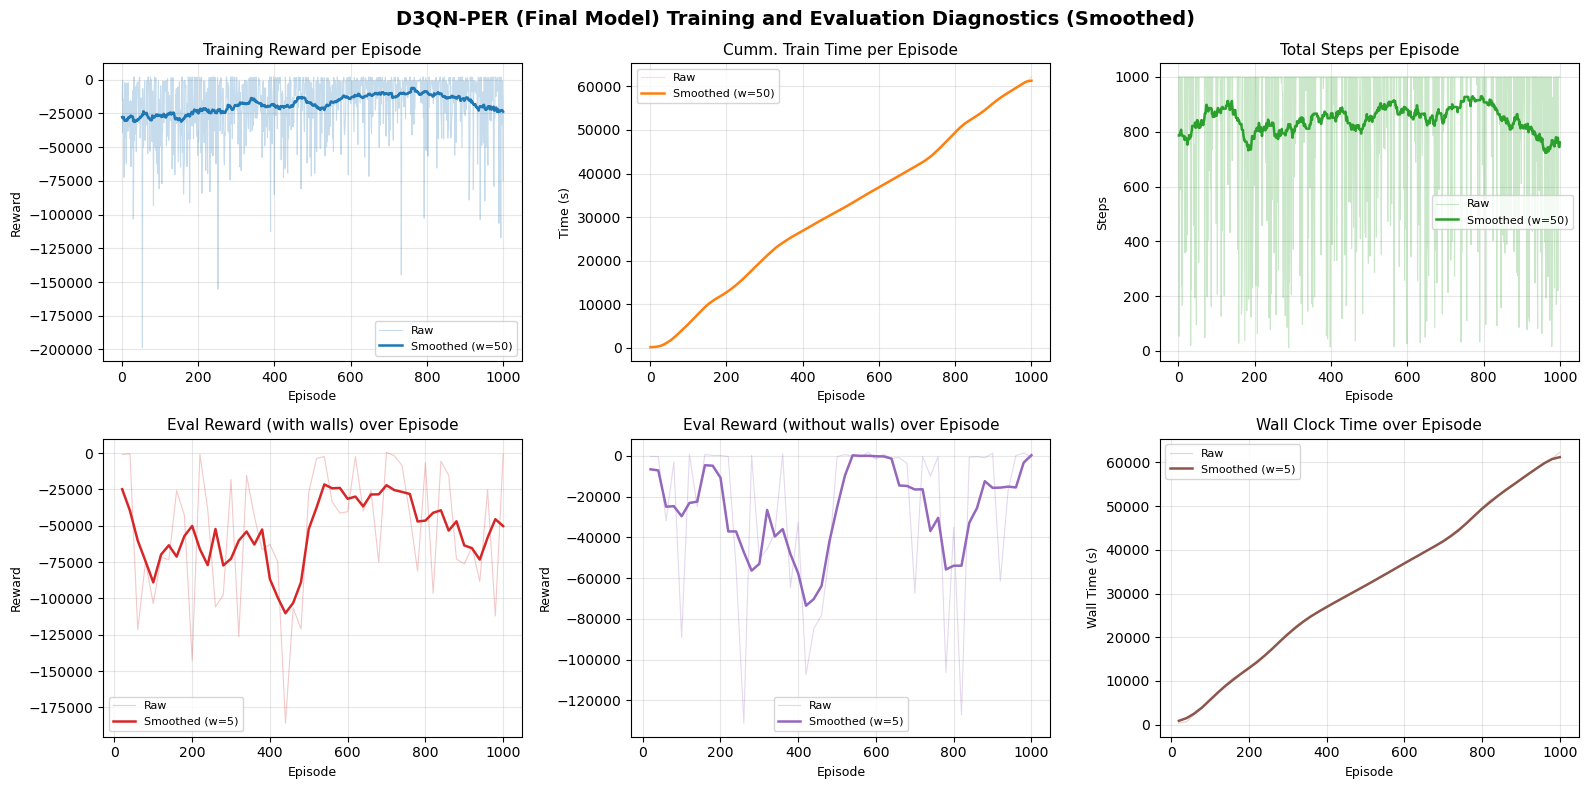

In [ ]:
def smooth(data, window=10):
    return uniform_filter1d(data, size=window)

# --- episode axes --- 
train_eps  = np.arange(1, len(d3qnPerTrainRewardsList) + 1)
eval_eps   = np.arange(20, 20 * len(d3qnPerEvalRewardsList1) + 1, 20)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("D3QN-PER (Final Model) Training and Evaluation Diagnostics (Smoothed)", fontsize=14, fontweight='bold')

plots = [
    (axes[0, 0], train_eps, d3qnPerTrainRewardsList,  "Training Reward per Episode", "Episode", "Reward", "tab:blue"),
    (axes[0, 1], train_eps, d3qnPerTrainTimeList, "Cumm. Train Time per Episode", "Episode", "Time (s)", "tab:orange"),
    (axes[0, 2], train_eps, d3qnPerTotalStepsList, "Total Steps per Episode", "Episode", "Steps", "tab:green"),
    (axes[1, 0], eval_eps,  d3qnPerEvalRewardsList1, "Eval Reward (with walls) over Episode", "Episode", "Reward", "tab:red"),
    (axes[1, 1], eval_eps,  d3qnPerEvalRewardsList2, "Eval Reward (without walls) over Episode", "Episode", "Reward", "tab:purple"),
    (axes[1, 2], eval_eps,  d3qnPerWallClockTimeList, "Wall Clock Time over Episode", "Episode", "Wall Time (s)", "tab:brown"),
]

for ax, x, raw, title, xlabel, ylabel, color in plots:
    raw_arr = np.array(raw)
    win = max(5, len(raw_arr) // 20)          # adaptive window
    sm  = smooth(raw_arr, window=win)

    ax.plot(x, raw_arr, alpha=0.25, color=color, linewidth=0.8, label="Raw")
    ax.plot(x, sm,      color=color, linewidth=1.8, label=f"Smoothed (w={win})")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("d3qn_per_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()